In [256]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

In [243]:
data_dir = r"C:\Users\lanaa\Downloads\npc_behavior_dataset_100k.csv"
model_dir = r"C:\Users\lanaa\Downloads\models"

In [244]:
validation_df = pd.read_csv(r"C:\Users\lanaa\Downloads\validation.csv")
test_df = pd.read_csv(r"C:\Users\lanaa\Downloads\test.csv")

In [245]:
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Validation shape: (15095, 25)
Test shape: (15240, 25)


In [246]:
print("\nAvailable model files:")
for file in sorted(os.listdir(model_dir)):
    print(" -", file)


Available model files:
 - ppo_evaluation_results.csv
 - ppo_npc.zip
 - ppo_npc_simulator
 - ppo_npc_simulator.zip
 - ppo_simulator_evaluation_results.csv
 - vec_normalize.pkl
 - vec_normalize_simulator.pkl


In [247]:
# Supervised learning validation results
supervised_results = pd.DataFrame({
    "Model" : [
        "Logistic Regression",
        "random Forest",
        "XGBoost"
    ],
    "Accuracy" : [
        0.6105,
        0.6686,
        0.6974
    ],
    "Macro F1" : [
        0.5527,
        0.5909,
        0.5898
    ]
})


In [248]:
## Supervised learning results
print(supervised_results.to_string(index=False))

print("\nBest model by Macro F1:")
best_model = supervised_results.loc[supervised_results["Macro F1"].idxmax()]

print(best_model)

              Model  Accuracy  Macro F1
Logistic Regression    0.6105    0.5527
      random Forest    0.6686    0.5909
            XGBoost    0.6974    0.5898

Best model by Macro F1:
Model       random Forest
Accuracy           0.6686
Macro F1           0.5909
Name: 1, dtype: object


In [250]:
# loading the PPO simulator evaluation results
ppo_results_path = os.path.join(
    model_dir,
    "ppo_simulator_evaluation_results.csv"
)

In [252]:
ppo_results = pd.read_csv(ppo_results_path)

In [253]:
print("\n---PPO SIMULATOR EVALUATION RESULTS---", ppo_results.columns.tolist())

print("\nResults:")
print(ppo_results)


---PPO SIMULATOR EVALUATION RESULTS--- ['mean_episode_reward', 'std_episode_reward', 'mean_episode_length', 'min_episode_length', 'max_episode_length', 'attack_percentage', 'chase_percentage', 'patrol_percentage', 'retreat_percentage', 'search_percentage', 'take_cover_percentage']

Results:
   mean_episode_reward  std_episode_reward  mean_episode_length  \
0                96.26           38.975279                 43.1   

   min_episode_length  max_episode_length  attack_percentage  \
0                  19                  60          15.220418   

   chase_percentage  patrol_percentage  retreat_percentage  search_percentage  \
0          2.041763           3.897912           24.083527          47.888631   

   take_cover_percentage  
0               6.867749  


In [255]:
# Comparing supervised learning models
supervised_results['Accuracy (%)'] = supervised_results['Accuracy'] * 100
supervised_results['Macro F1 (%)'] = supervised_results['Macro F1'] * 100

print(supervised_results[
    ['Model', 'Accuracy (%)', 'Macro F1 (%)']
    ].to_string(index=False))

              Model  Accuracy (%)  Macro F1 (%)
Logistic Regression         61.05         55.27
      random Forest         66.86         59.09
            XGBoost         69.74         58.98


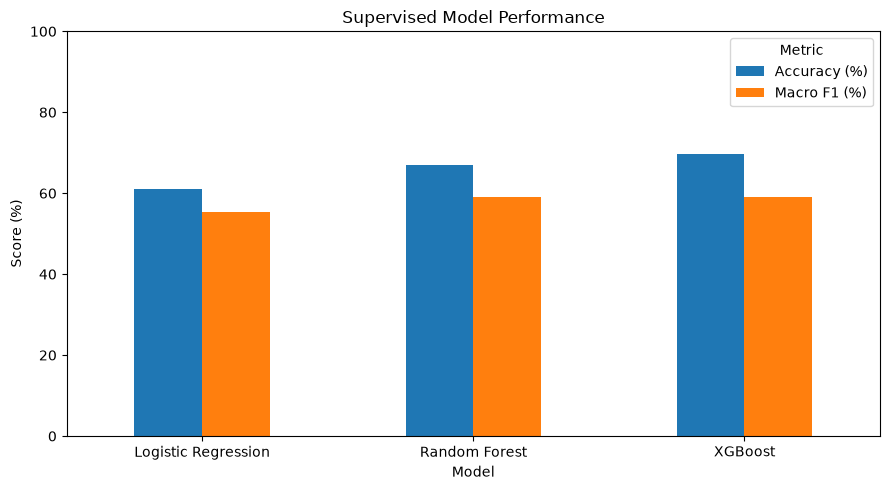

In [257]:
supervised_results['Model'] = supervised_results['Model'].replace({
    'random Forest' : "Random Forest"
})

ax = supervised_results.set_index('Model')[
    ['Accuracy (%)', 'Macro F1 (%)']
    ].plot( kind = 'bar' , figsize=(9,5))

plt.title("Supervised Model Performance")
plt.ylabel("Score (%)")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title = 'Metric')
plt.tight_layout()
plt.show()

**Visualizing Action Distribution**

---PPO ACTION DISTRIBUTION---
    Action  Percentage
    ATTACK   15.220418
     CHASE    2.041763
    PATROL    3.897912
   RETREAT   24.083527
    SEARCH   47.888631
TAKE_COVER    6.867749


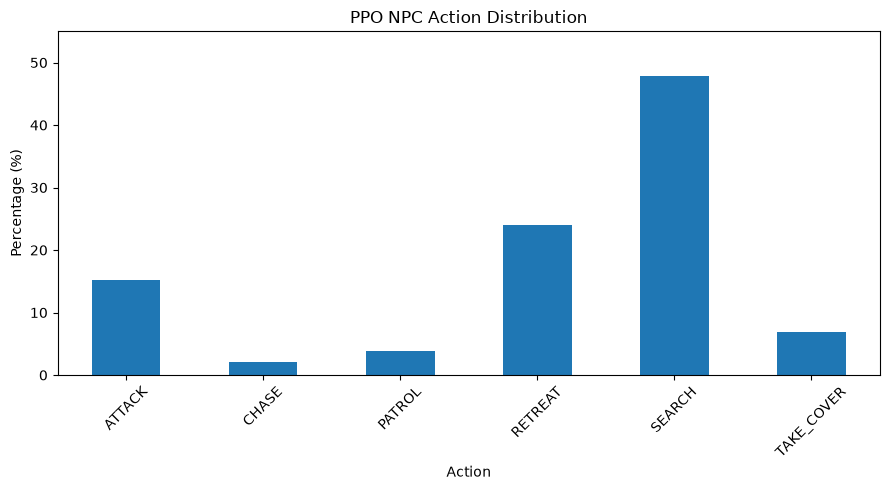

In [259]:
action_distribution = {
    "ATTACK" : ppo_results.loc[0, "attack_percentage"],
    "CHASE" : ppo_results.loc[0, "chase_percentage"],
    "PATROL" : ppo_results.loc[0, "patrol_percentage"],
    "RETREAT" : ppo_results.loc[0, "retreat_percentage"],
    "SEARCH" : ppo_results.loc[0, "search_percentage"],
    "TAKE_COVER" : ppo_results.loc[0, "take_cover_percentage"]
}

action_df = pd.DataFrame(list(action_distribution.items()), columns=['Action', 'Percentage'])

print("---PPO ACTION DISTRIBUTION---")
print(action_df.to_string(index=False))

# plot
ax = action_df.set_index("Action")["Percentage"].plot(kind='bar', figsize=(9, 5))
plt.title("PPO NPC Action Distribution")
plt.ylabel("Percentage (%)")
plt.xlabel("Action")
plt.xticks(rotation=45)
plt.ylim(0, 55)
plt.tight_layout()
plt.show()

In [260]:
# PPO evaluation summary

ppo_summary = pd.DataFrame({
    "Metric": [
        "Mean Episode Reward",
        "Std Episode Reward",
        "Mean Episode Length",
        "Min Episode Length",
        "Max Episode Length"
    ],
    "Value" : [
        ppo_results.loc[0, 'mean_episode_reward'],
        ppo_results.loc[0, 'std_episode_reward'],
        ppo_results.loc[0, 'mean_episode_length'],
        ppo_results.loc[0, 'min_episode_length'],
        ppo_results.loc[0, 'max_episode_length']
    ]
})
print("---PPO EVALUATION SUMMARY---")
print(ppo_summary.to_string(index=False))

---PPO EVALUATION SUMMARY---
             Metric     Value
Mean Episode Reward 96.260000
 Std Episode Reward 38.975279
Mean Episode Length 43.100000
 Min Episode Length 19.000000
 Max Episode Length 60.000000


In [261]:
metrics = ['Mean Episode Reward', 'Mean Episode Length']

values = [ppo_results.loc[0, 'mean_episode_reward'],
          ppo_results.loc[0, 'mean_episode_length']]

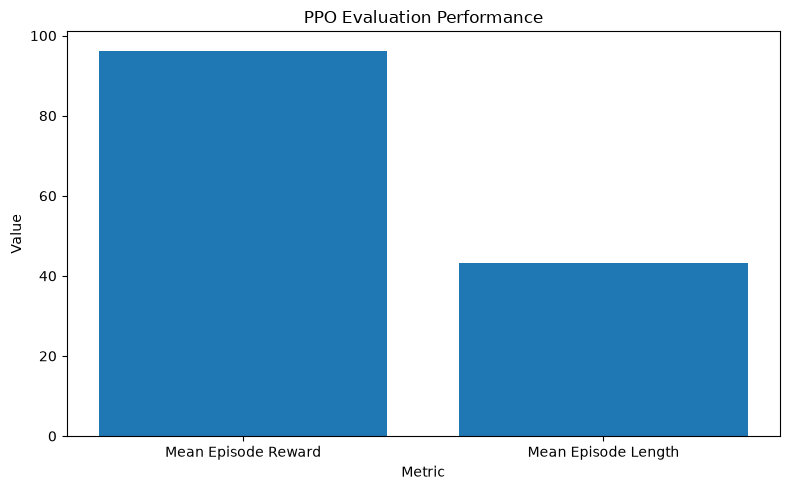

In [262]:
plt.figure(figsize=(8, 5))
plt.bar(metrics, values)
plt.title('PPO Evaluation Performance')
plt.ylabel("Value")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()

In [264]:
general_comp = pd.DataFrame({
    "Approach" : [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "PPO"
    ],
    "Accuracy" : [
        61.05,
        66.86,
        69.74,
        np.nan
    ],
    "Macro F1" : [
        55.27,
        59.09,
        58.98,
        np.nan
    ],
    "Mean Episode Reward" : [
        np.nan,
        np.nan,
        np.nan,
        ppo_results.loc[0, 'mean_episode_reward']
    ],
    "Mean Episode Length" : [
        np.nan,
        np.nan,
        np.nan,
        ppo_results.loc[0, 'mean_episode_length']
    ]
})
print("---FINAL MODEL COMPARISON---")
print(general_comp.to_string(index=False))

---FINAL MODEL COMPARISON---
           Approach  Accuracy  Macro F1  Mean Episode Reward  Mean Episode Length
Logistic Regression     61.05     55.27                  NaN                  NaN
      Random Forest     66.86     59.09                  NaN                  NaN
            XGBoost     69.74     58.98                  NaN                  NaN
                PPO       NaN       NaN                96.26                 43.1


In [267]:
final_comparison = pd.DataFrame({
    "Approach": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "PPO"
    ],
    "Accuracy": [
        61.05,
        66.86,
        69.74,
        np.nan
    ],
    "Macro F1": [
        55.27,
        59.09,
        58.98,
        np.nan
    ],
    "Mean Episode Reward": [
        np.nan,
        np.nan,
        np.nan,
        ppo_results.loc[0, "mean_episode_reward"]
    ],
    "Mean Episode Length": [
        np.nan,
        np.nan,
        np.nan,
        ppo_results.loc[0, "mean_episode_length"]
    ]
})

print("---FINAL MODEL COMPARISON---")
print(final_comparison.to_string(index=False))

---FINAL MODEL COMPARISON---
           Approach  Accuracy  Macro F1  Mean Episode Reward  Mean Episode Length
Logistic Regression     61.05     55.27                  NaN                  NaN
      Random Forest     66.86     59.09                  NaN                  NaN
            XGBoost     69.74     58.98                  NaN                  NaN
                PPO       NaN       NaN                96.26                 43.1


PER-CLASS F1 SCORE
     Class  Logistic Regression  Random Forest  XGBoost
    ATTACK                74.62          77.79    80.50
     CHASE                61.34          68.42    71.02
    PATROL                13.15          13.43     0.00
   RETREAT                55.83          60.06    61.44
    SEARCH                60.47          67.53    69.48
TAKE_COVER                66.24          67.31    71.44


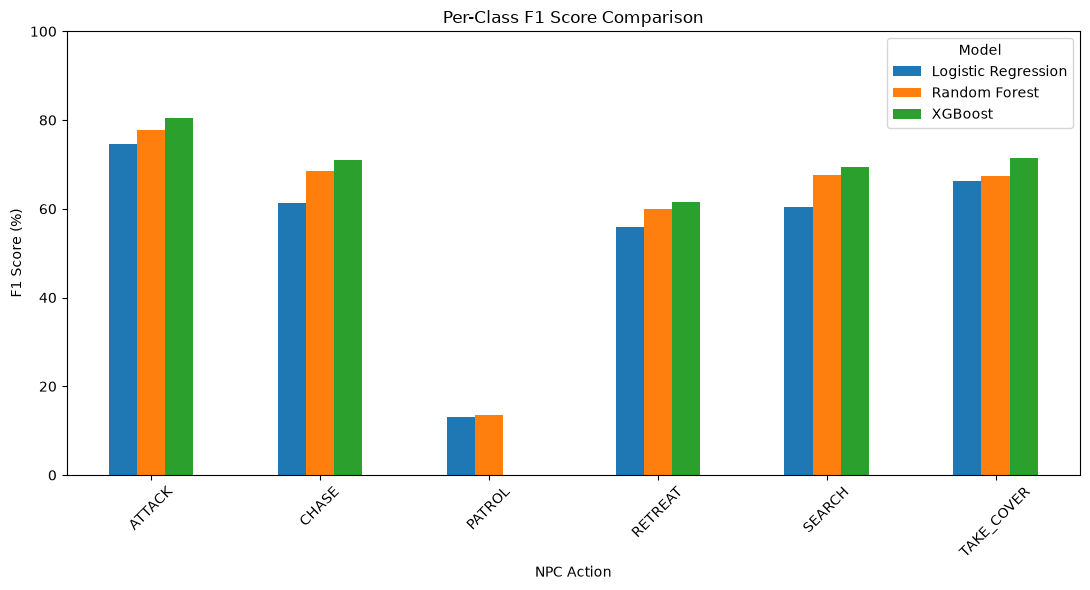

In [269]:
# Per-class F1 score comparison and visualization

class_f1 = pd.DataFrame({
    "Class": [
        "ATTACK",
        "CHASE",
        "PATROL",
        "RETREAT",
        "SEARCH",
        "TAKE_COVER"
    ],
    "Logistic Regression": [ 0.7462, 0.6134, 0.1315, 0.5583, 0.6047, 0.6624],
    "Random Forest": [0.7779, 0.6842, 0.1343, 0.6006, 0.6753, 0.6731],
    "XGBoost": [0.8050, 0.7102, 0.0000, 0.6144, 0.6948, 0.7144]})

class_f1_percent = class_f1.copy()
for column in class_f1_percent.columns[1:]:
    class_f1_percent[column] *= 100

print("PER-CLASS F1 SCORE")
print("=" * 80)
print(class_f1_percent.to_string(index=False))

ax = class_f1_percent.set_index("Class").plot(kind="bar",figsize=(11, 6))

plt.title("Per-Class F1 Score Comparison")
plt.ylabel("F1 Score (%)")
plt.xlabel("NPC Action")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.legend(title="Model")
plt.tight_layout()d
plt.show()

In [271]:
# Key findings from the experiments
best_accuracy_model = supervised_results.loc[
    supervised_results["Accuracy (%)"].idxmax()
]

best_macro_f1_model = supervised_results.loc[supervised_results["Macro F1 (%)"].idxmax()]

# Best and hardest classes based on the average F1 across supervised models
model_columns = ["Logistic Regression","Random Forest","XGBoost"]

class_f1_percent["Average F1 (%)"] = (class_f1_percent[model_columns].mean(axis=1))
best_class = class_f1_percent.loc[class_f1_percent["Average F1 (%)"].idxmax()]
hardest_class = class_f1_percent.loc[class_f1_percent["Average F1 (%)"].idxmin()]

print("KEY PROJECT FINDINGS")
print("=" * 60)

print(
    f"\nBest Accuracy Model: "
    f"{best_accuracy_model['Model']} "
    f"({best_accuracy_model['Accuracy (%)']:.2f}%)"
)

print(
    f"Best Macro F1 Model: "
    f"{best_macro_f1_model['Model']} "
    f"({best_macro_f1_model['Macro F1 (%)']:.2f}%)"
)

print(
    f"\nBest-performing action class: "
    f"{best_class['Class']} "
    f"(average F1: {best_class['Average F1 (%)']:.2f}%)"
)

print(
    f"Hardest action class: "
    f"{hardest_class['Class']} "
    f"(average F1: {hardest_class['Average F1 (%)']:.2f}%)"
)

print(
    f"\nPPO Mean Episode Reward: "
    f"{ppo_results.loc[0, 'mean_episode_reward']:.2f}"
)

print(
    f"PPO Mean Episode Length: "
    f"{ppo_results.loc[0, 'mean_episode_length']:.2f} steps"
)

KEY PROJECT FINDINGS

Best Accuracy Model: XGBoost (69.74%)
Best Macro F1 Model: Random Forest (59.09%)

Best-performing action class: ATTACK (average F1: 77.64%)
Hardest action class: PATROL (average F1: 8.86%)

PPO Mean Episode Reward: 96.26
PPO Mean Episode Length: 43.10 steps


## Final Findings

### Supervised Learning

The supervised learning experiments show that **XGBoost achieved the highest validation accuracy at 69.74%**, while **Random Forest achieved the highest Macro F1 score at 59.09%**.

Because Macro F1 gives equal importance to each NPC behavior class and the dataset is imbalanced, **Random Forest is selected as the best supervised model**.

### Per-Class Performance

Across the supervised models:

- **ATTACK** was the easiest behavior to predict, with the highest average F1 score.
- **PATROL** was the most difficult behavior to predict.
- The low PATROL performance is consistent with its relatively small representation in the dataset.
- XGBoost achieved the strongest F1 score for most individual classes, but its inability to correctly predict PATROL reduced its overall Macro F1.

### Reinforcement Learning

The PPO agent was evaluated in the simulated NPC environment.

The agent achieved:

- **Mean episode reward:** 96.26
- **Mean episode length:** 43.10 steps

The learned policy produced a diverse action distribution rather than collapsing to a single action. The most frequent behaviors were **SEARCH** and **RETREAT**, followed by **ATTACK**, **TAKE_COVER**, **PATROL**, and **CHASE**.

### Overall Conclusion

The experiments demonstrate two complementary approaches to NPC behavior:

1. **Supervised learning** learns to reproduce behavior patterns from historical NPC gameplay data.
2. **Reinforcement learning** learns a policy through interaction with a simulated environment and reward feedback.

The supervised model provides a strong baseline for behavior prediction, while PPO demonstrates how an NPC can learn decision-making behavior beyond direct imitation of the dataset.

## Project Deliverables

The completed project contains:

- Exploratory data analysis
- Episode-based train/validation/test splitting
- Feature preprocessing pipeline
- Logistic Regression baseline
- Random Forest classifier
- XGBoost classifier
- Custom NPC reinforcement learning environment
- PPO reinforcement learning agent
- PPO evaluation and behavior analysis
- Model comparison and final findings

### Saved Models and Results

The `models/` directory contains the trained PPO agent, normalization statistics, and evaluation results.

The `data/` directory contains the episode-separated training, validation, and test datasets.

The notebooks document the complete workflow from data exploration through supervised learning and reinforcement learning.